# SF Model Performance Check

This notebook evaluates the trained 4-parameter Structure Factor model on 1000 validation samples and plots `ground truth` vs `prediction` scatter plots for:

- `t_Cu`
- `t_polymer`
- `D`
- `sigma`

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

plt.style.use('default')
np.random.seed(42)
tf.random.set_seed(42)

TRAINSET_DIR = '/data/dust/user/zhaiyufe/TrainSet/ML_GISAXS_Yuxin'
RESULTS_DIR = '/data/dust/user/zhaiyufe/Models/ML_GISAXS_Yuxin/Results_SF'
MODEL_NAME = 'yuxin_sf_model_4para'
MASK_PATH = '/home/zhaiyufe/PycharmProjects/ML_GISAXS_Yuxin/TrainingNet/mask.npy'
NUM_SAMPLES = 1000
BATCH_SIZE = 64
INPUT_MODE = 'clean'
APPLY_MASK = True
LOG_EPS = 1e-8

TARGET_PARAM_NAMES = ['t_Cu', 't_polymer', 'D', 'sigma']
TARGET_MIN = np.array([0.0, 10.0, 4.0, 0.2], dtype=np.float32)
TARGET_MAX = np.array([25.0, 50.0, 20.0, 4.0], dtype=np.float32)

def denormalize_targets_np(targets):
    targets = np.asarray(targets, dtype=np.float32)
    return targets * (TARGET_MAX - TARGET_MIN) + TARGET_MIN

PATH_MODEL = os.path.join(RESULTS_DIR, f'{MODEL_NAME}.keras')
PATH_CHECKPOINT = os.path.join(RESULTS_DIR, f'{MODEL_NAME}.checkpoint.keras')
MODEL_PATH = PATH_MODEL if os.path.exists(PATH_MODEL) else PATH_CHECKPOINT

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'Model file not found: {MODEL_PATH}')
if not os.path.exists(MASK_PATH):
    raise FileNotFoundError(f'Mask file not found: {MASK_PATH}')

print('Model path:', MODEL_PATH)
print('Trainset dir:', TRAINSET_DIR)
print('Mask path:', MASK_PATH)
print('Requested samples:', NUM_SAMPLES)

FileNotFoundError: Model file not found: /data/dust/user/zhaiyufe/Models/ML_GISAXS_Yuxin/Results_SF/yuxin_sf_model_4para.checkpoint.keras

In [8]:
file_list = sorted(glob.glob(os.path.join(TRAINSET_DIR, '**', '*_aux.tfrecord'), recursive=True))
if not file_list:
    raise RuntimeError('No *_aux.tfrecord files found.')

def has_readable_record(path):
    try:
        for _ in tf.data.TFRecordDataset(path).take(1):
            return True
    except Exception:
        return False
    return False

good_files = [path for path in file_list if has_readable_record(path)]
if not good_files:
    raise RuntimeError('No readable *_aux.tfrecord files found.')

split_idx = max(1, int(0.8 * len(good_files)))
if split_idx >= len(good_files):
    split_idx = len(good_files) - 1

val_files = good_files[split_idx:] if split_idx > 0 else good_files
if not val_files:
    val_files = good_files

def infer_shapes_from_tfrecord(filename):
    sample_file = filename[0] if isinstance(filename, (list, tuple)) else filename
    input_len = None
    output_len = None
    for raw in tf.data.TFRecordDataset(sample_file).take(1):
        example = tf.train.Example()
        example.ParseFromString(raw.numpy())
        input_len = len(example.features.feature['input'].float_list.value)
        output_len = len(example.features.feature['output'].float_list.value)
    if input_len is None or output_len is None:
        raise RuntimeError(f'Could not infer shapes from {sample_file}')
    input_side = int(round(input_len ** 0.5))
    return (input_side, input_side, 1), (output_len,)

input_shape, output_shape = infer_shapes_from_tfrecord(val_files)
print('Validation files:', len(val_files))
print('Input shape:', input_shape)
print('Output shape:', output_shape)

Validation files: 24
Input shape: (256, 256, 1)
Output shape: (6,)


In [ ]:
def load_mask_tensors(mask_path, image_shape):
    mask = np.load(mask_path)
    if mask.ndim == 2:
        mask = mask[..., None]
    if mask.shape != image_shape:
        raise ValueError(f'Mask shape {mask.shape} does not match input shape {image_shape}')
    return tf.constant(mask.astype(np.float32)), tf.constant(mask.astype(bool))

fixed_mask_float_tf, fixed_mask_bool_tf = load_mask_tensors(MASK_PATH, input_shape)

def log_normalize_tf(image):
    image = tf.cast(image, tf.float32)
    max_val = tf.reduce_max(image)
    scale = tf.math.divide_no_nan(tf.constant(np.e, dtype=image.dtype), max_val + tf.constant(LOG_EPS, dtype=image.dtype))
    scaled = image * scale
    logged = tf.math.log(scaled + tf.constant(LOG_EPS, dtype=image.dtype))
    return tf.where(tf.math.is_finite(logged), logged, tf.fill(tf.shape(logged), tf.constant(-1.0, dtype=image.dtype)))

def apply_fixed_mask_tf(image):
    return tf.where(fixed_mask_bool_tf, tf.fill(tf.shape(image), tf.constant(-1.0, dtype=image.dtype)), image)

def filter_valid_output(record):
    return tf.reduce_all(record['output'][:4] >= 0.0)

def parse_example(example_proto):
    feature_description = {
        'input': tf.io.FixedLenFeature(input_shape, tf.float32),
        'output': tf.io.FixedLenFeature(output_shape, tf.float32),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    parsed['output'] = parsed['output'][:4]
    return parsed

def replace_nan_with_zero(record):
    record['input'] = tf.where(tf.math.is_nan(record['input']), tf.fill(tf.shape(record['input']), tf.constant(1e-10, dtype=record['input'].dtype)), record['input'])
    record['output'] = tf.where(tf.math.is_nan(record['output']), tf.fill(tf.shape(record['output']), tf.constant(1e-10, dtype=record['output'].dtype)), record['output'])
    return record

def preprocess_clean_input(record):
    image = log_normalize_tf(record['input'])
    if APPLY_MASK:
        image = apply_fixed_mask_tf(image)
    record['input'] = image
    return record

def add_mask_channel(record):
    record['input'] = tf.concat([record['input'], fixed_mask_float_tf], axis=-1)
    return record

def split_input_output(record):
    return record['input'], record['output']

def load_eval_dataset(files):
    dataset = tf.data.TFRecordDataset(files, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.ignore_errors()
    dataset = dataset.map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.filter(filter_valid_output)
    dataset = dataset.map(replace_nan_with_zero, num_parallel_calls=tf.data.AUTOTUNE)
    if INPUT_MODE == 'clean':
        dataset = dataset.map(preprocess_clean_input, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(add_mask_channel, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(split_input_output, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.take(NUM_SAMPLES)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

eval_dataset = load_eval_dataset(val_files)
print(eval_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


In [ ]:
model = load_model(MODEL_PATH, safe_mode=False)
model.summary()

all_truth = []
all_pred = []

for batch_x, batch_y in eval_dataset:
    prediction_dict = model.predict(batch_x, verbose=0)
    prediction_normalized = np.concatenate([
        prediction_dict['branch_thickness'],
        prediction_dict['branch_size'],
    ], axis=-1)
    prediction = denormalize_targets_np(prediction_normalized)
    all_truth.append(batch_y.numpy())
    all_pred.append(prediction)

y_true = np.concatenate(all_truth, axis=0)
y_pred = np.concatenate(all_pred, axis=0)

parameter_names = TARGET_PARAM_NAMES
print('Evaluated samples:', len(y_true))
print('Prediction shape:', y_pred.shape)

Model: "gated_three_branch"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 img_and_mask (InputLayer)   [(None, 256, 256, 2)]        0         []                            
                                                                                                  
 tf.__operators__.getitem_1  (None, 256, 256, 1)          0         ['img_and_mask[0][0]']        
  (SlicingOpLambda)                                                                               
                                                                                                  
 tf.__operators__.getitem (  (None, 256, 256, 1)          0         ['img_and_mask[0][0]']        
 SlicingOpLambda)                                                                                 
                                                                                 

In [5]:
rows = []
for idx, name in enumerate(parameter_names):
    gt = y_true[:, idx]
    pred = y_pred[:, idx]
    mae = np.mean(np.abs(pred - gt))
    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    corr = np.corrcoef(gt, pred)[0, 1] if np.std(gt) > 0 and np.std(pred) > 0 else np.nan
    rows.append({'parameter': name, 'MAE': mae, 'RMSE': rmse, 'Pearson_r': corr})

metrics_df = pd.DataFrame(rows)
metrics_df

,parameter,MAE,RMSE,Pearson_r
0,t_Cu,4.353604,4.873181,0.346921
1,t_polymer,12.077661,14.685617,0.288271
2,D,5.351156,8.178601,0.487862
3,sigma,1.042173,1.618105,0.435709
4,DW,0.075199,0.087142,0.000130
5,DW_r,0.475930,0.570192,0.265953


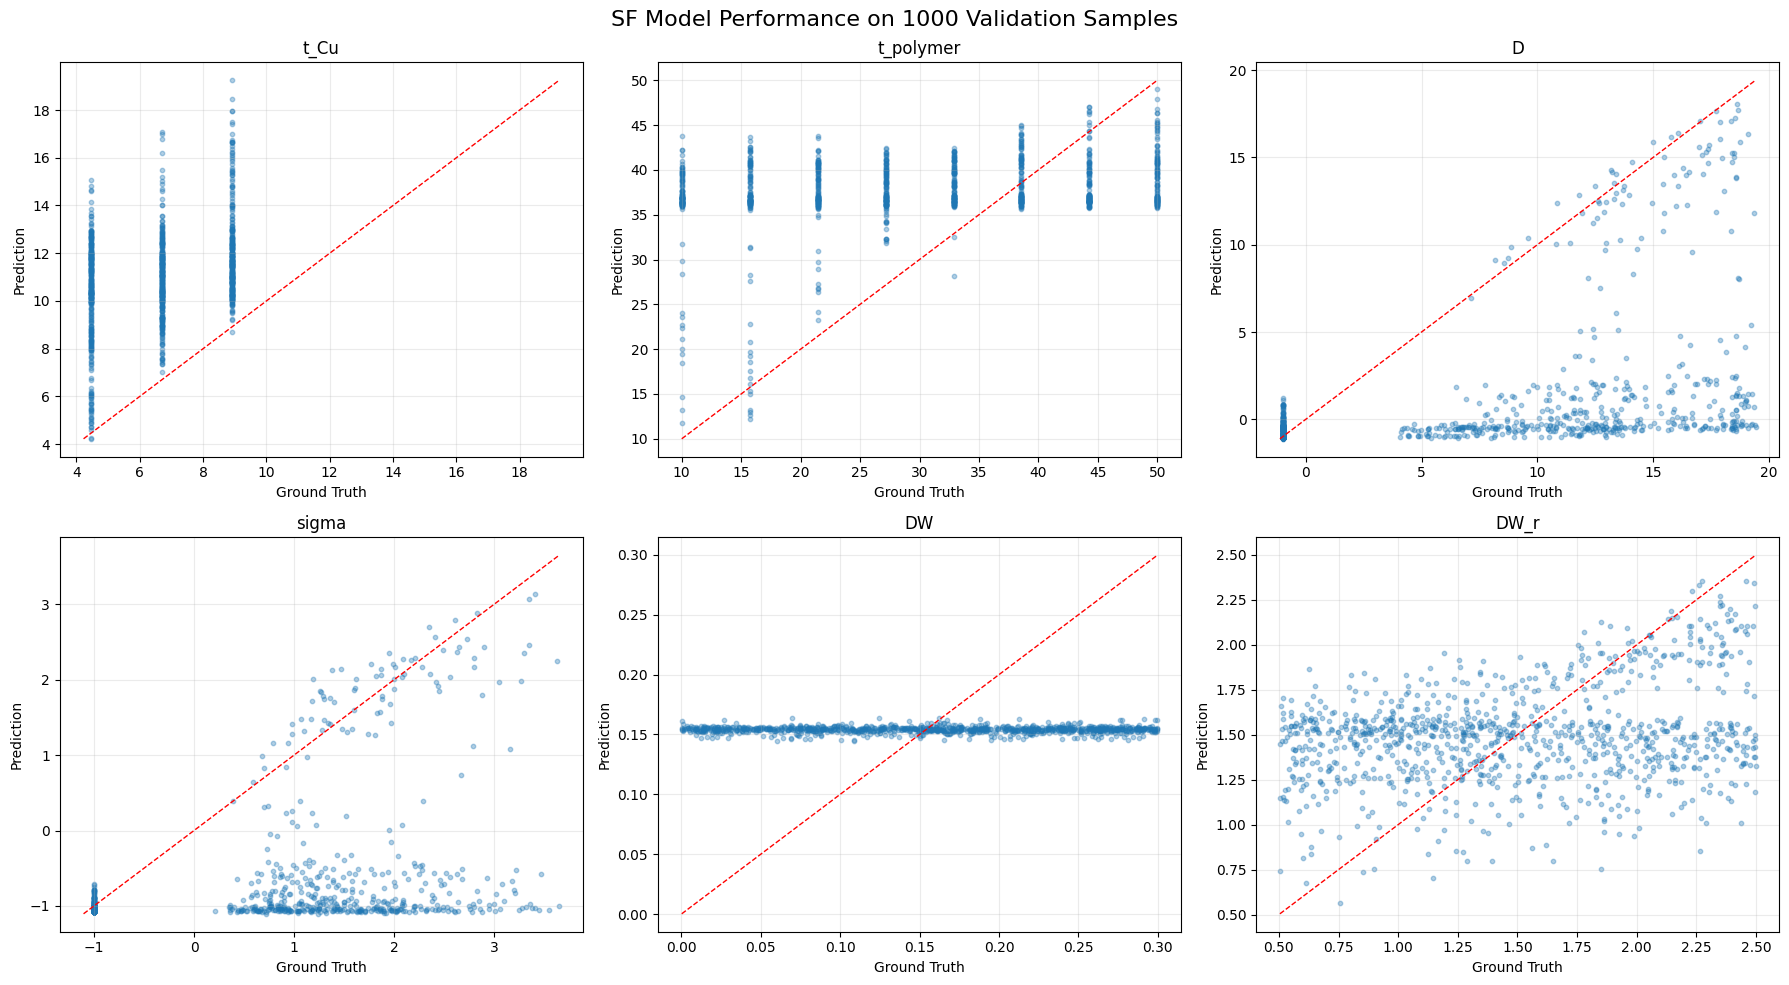

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (ax, name) in enumerate(zip(axes, parameter_names)):
    gt = y_true[:, idx]
    pred = y_pred[:, idx]
    ax.scatter(gt, pred, s=10, alpha=0.35)
    low = min(gt.min(), pred.min())
    high = max(gt.max(), pred.max())
    ax.plot([low, high], [low, high], 'r--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediction')
    ax.grid(alpha=0.25)

fig.suptitle(f'SF 4-Parameter Model Performance on {len(y_true)} Validation Samples', fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(y_true, columns=[f'{name}_gt' for name in parameter_names])
for idx, name in enumerate(parameter_names):
    results_df[f'{name}_pred'] = y_pred[:, idx]

results_df.head()